In [6]:
import openeo

In [7]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [8]:
aoi = {
    "type": "Polygon",
    "coordinates": [
          [
            [
              112.0735328,
              -7.4371755
            ],
            [
              112.0735328,
              -7.4371755
            ],
            [
              112.0735328,
              -7.4371755
            ],
            [
              112.0735328,
              -7.4371755
            ]
          ]
        ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2026-06-01"],
    spatial_extent={
        "west": 112.00,
        "south": -7.50,
        "east": 112.15,
        "north": -7.40
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [9]:
job = s5post.execute_batch(title="NO2 in Jombang26", outputfile="NO2Jombang26.nc")

0:00:00 Job 'j-26060304130848f4b520937f326208e6': send 'start'
0:00:07 Job 'j-26060304130848f4b520937f326208e6': queued (progress 0%)
0:00:13 Job 'j-26060304130848f4b520937f326208e6': queued (progress 0%)
0:00:19 Job 'j-26060304130848f4b520937f326208e6': queued (progress 0%)
0:00:27 Job 'j-26060304130848f4b520937f326208e6': queued (progress 0%)
0:00:37 Job 'j-26060304130848f4b520937f326208e6': queued (progress 0%)
0:00:50 Job 'j-26060304130848f4b520937f326208e6': queued (progress 0%)
0:01:05 Job 'j-26060304130848f4b520937f326208e6': running (progress N/A)
0:01:25 Job 'j-26060304130848f4b520937f326208e6': running (progress N/A)
0:01:49 Job 'j-26060304130848f4b520937f326208e6': running (progress N/A)
0:02:19 Job 'j-26060304130848f4b520937f326208e6': running (progress N/A)
0:02:57 Job 'j-26060304130848f4b520937f326208e6': running (progress N/A)
0:03:44 Job 'j-26060304130848f4b520937f326208e6': running (progress N/A)
0:04:42 Job 'j-26060304130848f4b520937f326208e6': running (progress N/A)


In [30]:
import netCDF4

file_path = "NO2Jombang26.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2 725

print(len(no2[0]))
# panjang data perbaris 9

print(len(no2[0][0]))
# panjang perdata 8

print(no2[0][0][0])
# 3.7701793e-05

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
968
3
3
4.2193067e-05


In [31]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[4.2193067201878875e-05 3.282297620899044e-05 2.2592344976146705e-05]
 [2.595133446448017e-05 3.282297620899044e-05 4.129485387238674e-05]
 [2.8745240342686884e-05 2.812943967001047e-05 4.129485387238674e-05]]
[[2.363367639190983e-05 3.756273872568272e-05 3.756273872568272e-05]
 [2.5280478439526632e-05 3.756273872568272e-05 5.891578257433139e-05]
 [3.5354281862964854e-05 5.891578257433139e-05 5.891578257433139e-05]]
[[-- -- --]
 [-- -- --]
 [1.2137440535298083e-05 1.2137440535298083e-05 --]]
[[1.6432019037893042e-05 2.0944942662026733e-05 3.290186941740103e-05]
 [3.137972089461982e-05 2.6521434847381897e-05 3.290186941740103e-05]
 [4.34483663411811e-05 3.995886436314322e-05 2.9368313334998675e-05]]
[[-- -- 3.555463990778662e-05]
 [-- -- 5.344758028513752e-05]
 [-- 2.824453440553043e-05 5.344758028513752e-05]]
[[3.57818826159928e-05 3.17629637720529e-05 2.764822420431301e-05]
 [4.155400529270992e-05 3.17629637720529e-05 2.6783660359797068e-05]
 [4.8956051614368334e

In [32]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

In [33]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

In [34]:
df = pd.DataFrame({
    "date": dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Jombang26_timeseries.csv", index=False)

In [35]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Jombang26_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2026-06-01"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 7
Daftar tanggal missing:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-23', '2024-08-12',
               '2025-01-30', '2025-01-31', '2026-06-01'],
              dtype='datetime64[ns]', freq=None)


In [36]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2023-10-01", end="2026-06-01", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# (Opsional) jika masih ada NaN di bagian awal/akhir bisa gunakan forward/backward fill
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("no2_timeseries_interpolated.csv")

C:\Users\hp\AppData\Local\Temp\ipykernel_14936\479519108.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 40
         date       NO2
16 2023-10-17  0.000044
17 2023-10-18  0.000044
19 2023-10-20  0.000047
23 2023-10-24  0.000044
24 2023-10-25  0.000046


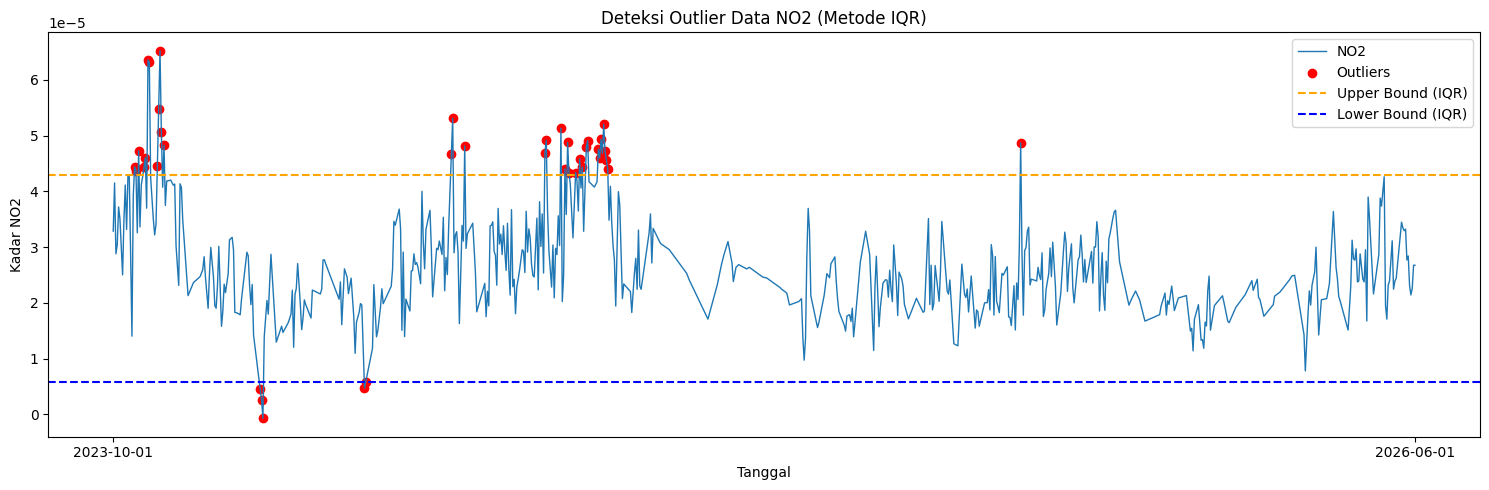

In [38]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'], 
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [39]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 40
Jumlah missing setelah interpolasi: 0


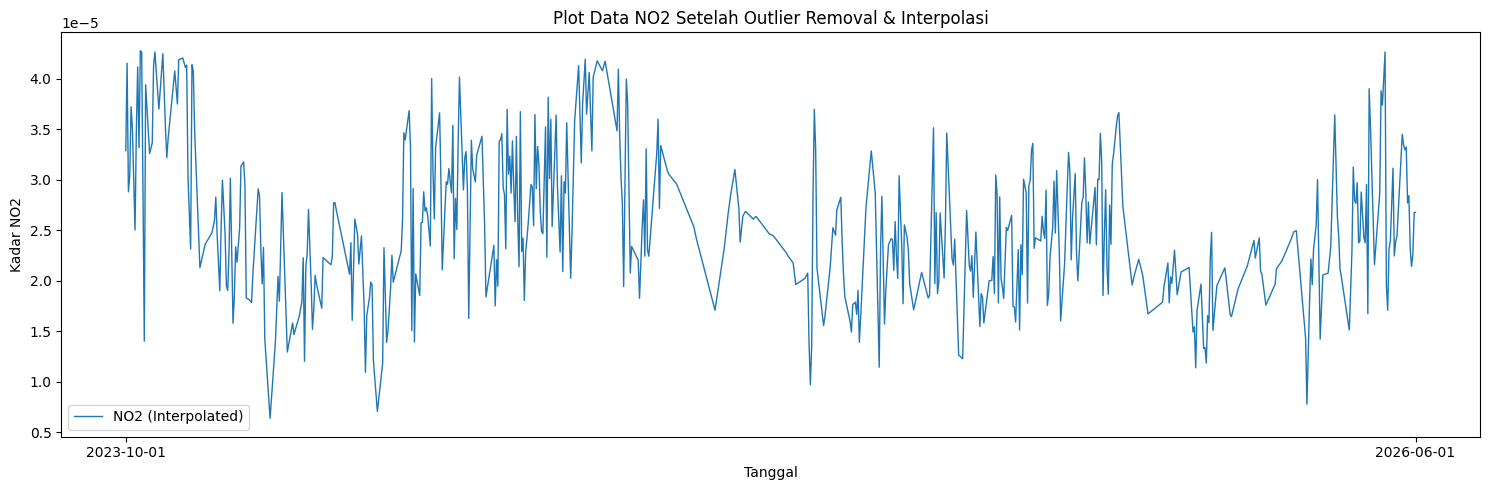

In [40]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

In [43]:
import pandas as pd

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()
    
    # Membuat fitur t-4 sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)
    
    # Label hari H
    df_supervised['NO2(t)'] = data
    
    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)
    
    return df_supervised

# contoh penggunaan
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

# Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan nilai korelasi
print(correlations)

NO2(t-30)    0.274449
NO2(t-29)    0.285806
NO2(t-28)    0.284978
NO2(t-27)    0.295839
NO2(t-26)    0.311357
NO2(t-25)    0.312222
NO2(t-24)    0.315634
NO2(t-23)    0.319236
NO2(t-22)    0.323216
NO2(t-21)    0.334234
NO2(t-20)    0.342498
NO2(t-19)    0.386789
NO2(t-18)    0.402626
NO2(t-17)    0.415225
NO2(t-16)    0.446812
NO2(t-15)    0.439168
NO2(t-14)    0.453578
NO2(t-13)    0.425695
NO2(t-12)    0.452099
NO2(t-11)    0.465570
NO2(t-10)    0.469158
NO2(t-9)     0.479097
NO2(t-8)     0.480700
NO2(t-7)     0.491631
NO2(t-6)     0.510926
NO2(t-5)     0.527930
NO2(t-4)     0.548932
NO2(t-3)     0.606192
NO2(t-2)     0.695511
NO2(t-1)     0.801048
dtype: float64


In [44]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.509174  0.640307  0.447479  0.472138  0.575063
5    0.640307  0.447479  0.472138  0.575063  0.543173
6    0.447479  0.472138  0.575063  0.543173  0.466703
7    0.472138  0.575063  0.543173  0.466703  0.390233
8    0.575063  0.543173  0.466703  0.390233  0.540326
..        ...       ...       ...       ...       ...
970  0.510359  0.514684  0.430813  0.441692  0.361490
971  0.514684  0.430813  0.441692  0.361490  0.335577
972  0.430813  0.441692  0.361490  0.335577  0.353938
973  0.441692  0.361490  0.335577  0.353938  0.416509
974  0.361490  0.335577  0.353938  0.416509  0.416509

[971 rows x 5 columns]
(971, 5)


In [45]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.509174  0.640307  0.447479  0.472138  0.575063  0.543173  0.466703   
11    0.640307  0.447479  0.472138  0.575063  0.543173  0.466703  0.390233   
12    0.447479  0.472138  0.575063  0.543173  0.466703  0.390233  0.540326   
13    0.472138  0.575063  0.543173  0.466703  0.390233  0.540326  0.634722   
14    0.575063  0.543173  0.466703  0.390233  0.540326  0.634722  0.513664   
..         ...       ...       ...       ...       ...       ...       ...   
970   0.380882  0.419080  0.457278  0.495477  0.533675  0.518251  0.510359   
971   0.419080  0.457278  0.495477  0.533675  0.518251  0.510359  0.514684   
972   0.457278  0.495477  0.533675  0.518251  0.510359  0.514684  0.430813   
973   0.495477  0.533675  0.518251  0.510359  0.514684  0.430813  0.441692   
974   0.533675  0.518251  0.510359  0.514684  0.430813  0.441692  0.361490   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.390233  0.

In [46]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 776 — Test Size: 195
RMSE: 0.055871
R² Score: 0.5408
MAPE: 10.8314%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 772 — Test Size: 193
RMSE: 0.057891
R² Score: 0.5086
MAPE: 11.8906%


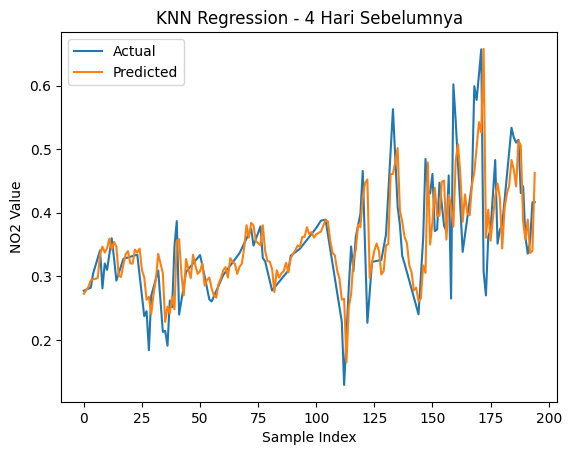

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

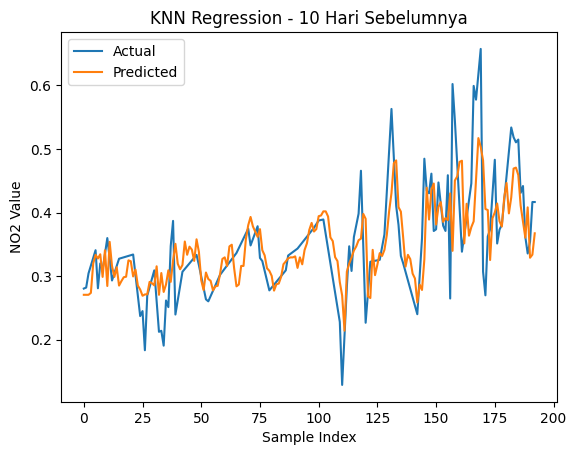

In [48]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()